# Packages import

In [82]:
import torch 

import torch.nn as nn

import torch.optim as optim

import nltk

import regex as re

import pandas as pd

import numpy as np



from matplotlib import pyplot as plt

from nltk.corpus import stopwords

from torch.utils.data import DataLoader, Dataset

from collections import Counter

import torch.nn.functional as F

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# ANFIS implementation

Code take from: https://github.com/jfpower/anfis-pytorch/blob/master/anfis.py

In [83]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
'''
    ANFIS in torch: the ANFIS layers
    @author: James Power <james.power@mu.ie> Apr 12 18:13:10 2019
    Acknowledgement: twmeggs' implementation of ANFIS in Python was very
    useful in understanding how the ANFIS structures could be interpreted:
        https://github.com/twmeggs/anfis
'''

import itertools
from collections import OrderedDict

import numpy as np

import torch
import torch.nn.functional as F


dtype = torch.float


class FuzzifyVariable(torch.nn.Module):
    '''
        Represents a single fuzzy variable, holds a list of its MFs.
        Forward pass will then fuzzify the input (value for each MF).
    '''
    def __init__(self, mfdefs):
        super(FuzzifyVariable, self).__init__()
        if isinstance(mfdefs, list):  # No MF names supplied
            mfnames = ['mf{}'.format(i) for i in range(len(mfdefs))]
            mfdefs = OrderedDict(zip(mfnames, mfdefs))
        self.mfdefs = torch.nn.ModuleDict(mfdefs)
        self.padding = 0

    @property
    def num_mfs(self):
        '''Return the actual number of MFs (ignoring any padding)'''
        return len(self.mfdefs)

    def members(self):
        '''
            Return an iterator over this variables's membership functions.
            Yields tuples of the form (mf-name, MembFunc-object)
        '''
        return self.mfdefs.items()

    def pad_to(self, new_size):
        '''
            Will pad result of forward-pass (with zeros) so it has new_size,
            i.e. as if it had new_size MFs.
        '''
        self.padding = new_size - len(self.mfdefs)

    def fuzzify(self, x):
        '''
            Yield a list of (mf-name, fuzzy values) for these input values.
        '''
        for mfname, mfdef in self.mfdefs.items():
            yvals = mfdef(x)
            yield(mfname, yvals)

    def forward(self, x):
        '''
            Return a tensor giving the membership value for each MF.
            x.shape: n_cases
            y.shape: n_cases * n_mfs
        '''
        y_pred = torch.cat([mf(x) for mf in self.mfdefs.values()], dim=1)
        if self.padding > 0:
            y_pred = torch.cat([y_pred,
                                torch.zeros(x.shape[0], self.padding)], dim=1)
        return y_pred


class FuzzifyLayer(torch.nn.Module):
    '''
        A list of fuzzy variables, representing the inputs to the FIS.
        Forward pass will fuzzify each variable individually.
        We pad the variables so they all seem to have the same number of MFs,
        as this allows us to put all results in the same tensor.
    '''
    def __init__(self, varmfs, varnames=None):
        super(FuzzifyLayer, self).__init__()
        if not varnames:
            self.varnames = ['x{}'.format(i) for i in range(len(varmfs))]
        else:
            self.varnames = list(varnames)
        maxmfs = max([var.num_mfs for var in varmfs])
        for var in varmfs:
            var.pad_to(maxmfs)
        self.varmfs = torch.nn.ModuleDict(zip(self.varnames, varmfs))

    @property
    def num_in(self):
        '''Return the number of input variables'''
        return len(self.varmfs)

    @property
    def max_mfs(self):
        ''' Return the max number of MFs in any variable'''
        return max([var.num_mfs for var in self.varmfs.values()])

    def __repr__(self):
        '''
            Print the variables, MFS and their parameters (for info only)
        '''
        r = ['Input variables']
        for varname, members in self.varmfs.items():
            r.append('Variable {}'.format(varname))
            for mfname, mfdef in members.mfdefs.items():
                r.append('- {}: {}({})'.format(mfname,
                         mfdef.__class__.__name__,
                         ', '.join(['{}={}'.format(n, p.item())
                                   for n, p in mfdef.named_parameters()])))
        return '\n'.join(r)

    def forward(self, x):
        ''' Fuzzyify each variable's value using each of its corresponding mfs.
            x.shape = n_cases * n_in
            y.shape = n_cases * n_in * n_mfs
        '''
        assert x.shape[1] == self.num_in,\
            '{} is wrong no. of input values'.format(self.num_in)
        y_pred = torch.stack([var(x[:, i:i+1])
                              for i, var in enumerate(self.varmfs.values())],
                             dim=1)
        return y_pred


class AntecedentLayer(torch.nn.Module):
    '''
        Form the 'rules' by taking all possible combinations of the MFs
        for each variable. Forward pass then calculates the fire-strengths.
    '''
    def __init__(self, varlist):
        super(AntecedentLayer, self).__init__()
        # Count the (actual) mfs for each variable:
        mf_count = [var.num_mfs for var in varlist]
        # Now make the MF indices for each rule:
        mf_indices = itertools.product(*[range(n) for n in mf_count])
        self.mf_indices = torch.tensor(list(mf_indices))
        # mf_indices.shape is n_rules * n_in

    def num_rules(self):
        return len(self.mf_indices)

    def extra_repr(self, varlist=None):
        if not varlist:
            return None
        row_ants = []
        mf_count = [len(fv.mfdefs) for fv in varlist.values()]
        for rule_idx in itertools.product(*[range(n) for n in mf_count]):
            thisrule = []
            for (varname, fv), i in zip(varlist.items(), rule_idx):
                thisrule.append('{} is {}'
                                .format(varname, list(fv.mfdefs.keys())[i]))
            row_ants.append(' and '.join(thisrule))
        return '\n'.join(row_ants)

    def forward(self, x):
        ''' Calculate the fire-strength for (the antecedent of) each rule
            x.shape = n_cases * n_in * n_mfs
            y.shape = n_cases * n_rules
        '''
        # Expand (repeat) the rule indices to equal the batch size:
        batch_indices = self.mf_indices.expand((x.shape[0], -1, -1))
        # Then use these indices to populate the rule-antecedents
        ants = torch.gather(x.transpose(1, 2), 1, batch_indices)
        # ants.shape is n_cases * n_rules * n_in
        # Last, take the AND (= product) for each rule-antecedent
        rules = torch.prod(ants, dim=2)
        return rules


class ConsequentLayer(torch.nn.Module):
    '''
        A simple linear layer to represent the TSK consequents.
        Hybrid learning, so use MSE (not BP) to adjust coefficients.
        Hence, coeffs are no longer parameters for backprop.
    '''
    def __init__(self, d_in, d_rule, d_out):
        super(ConsequentLayer, self).__init__()
        c_shape = torch.Size([d_rule, d_out, d_in+1])
        self._coeff = torch.zeros(c_shape, dtype=dtype, requires_grad=True)

    @property
    def coeff(self):
        '''
            Record the (current) coefficients for all the rules
            coeff.shape: n_rules * n_out * (n_in+1)
        '''
        return self._coeff

    @coeff.setter
    def coeff(self, new_coeff):
        '''
            Record new coefficients for all the rules
            coeff: for each rule, for each output variable:
                   a coefficient for each input variable, plus a constant
        '''
        assert new_coeff.shape == self.coeff.shape, \
            'Coeff shape should be {}, but is actually {}'\
            .format(self.coeff.shape, new_coeff.shape)
        self._coeff = new_coeff

    def fit_coeff(self, x, weights, y_actual):
        '''
            Use LSE to solve for coeff: y_actual = coeff * (weighted)x
                  x.shape: n_cases * n_in
            weights.shape: n_cases * n_rules
            [ coeff.shape: n_rules * n_out * (n_in+1) ]
                  y.shape: n_cases * n_out
        '''
        # Append 1 to each list of input vals, for the constant term:
        x_plus = torch.cat([x, torch.ones(x.shape[0], 1)], dim=1)
        # Shape of weighted_x is n_cases * n_rules * (n_in+1)
        weighted_x = torch.einsum('bp, bq -> bpq', weights, x_plus)
        # Can't have value 0 for weights, or LSE won't work:
        weighted_x[weighted_x == 0] = 1e-12
        # Squash x and y down to 2D matrices for gels:
        weighted_x_2d = weighted_x.view(weighted_x.shape[0], -1)
        y_actual_2d = y_actual.view(y_actual.shape[0], -1)
        # Use gels to do LSE, then pick out the solution rows:
        try:
            coeff_2d, _ = torch.gels(y_actual_2d, weighted_x_2d)
        except RuntimeError as e:
            print('Internal error in gels', e)
            print('Weights are:', weighted_x)
            raise e
        coeff_2d = coeff_2d[0:weighted_x_2d.shape[1]]
        # Reshape to 3D tensor: divide by rules, n_in+1, then swap last 2 dims
        self.coeff = coeff_2d.view(weights.shape[1], x.shape[1]+1, -1)\
            .transpose(1, 2)
        # coeff dim is thus: n_rules * n_out * (n_in+1)

    def forward(self, x):
        '''
            Calculate: y = coeff * x + const   [NB: no weights yet]
                  x.shape: n_cases * n_in
              coeff.shape: n_rules * n_out * (n_in+1)
                  y.shape: n_cases * n_out * n_rules
        '''
        # Append 1 to each list of input vals, for the constant term:
        x_plus = torch.cat([x, torch.ones(x.shape[0], 1)], dim=1)
        # Need to switch dimansion for the multipy, then switch back:
        y_pred = torch.matmul(self.coeff, x_plus.t())
        return y_pred.transpose(0, 2)  # swaps cases and rules


class PlainConsequentLayer(ConsequentLayer):
    '''
        A linear layer to represent the TSK consequents.
        Not hybrid learning, so coefficients are backprop-learnable parameters.
    '''
    def __init__(self, *params):
        super(PlainConsequentLayer, self).__init__(*params)
        self.register_parameter('coefficients',
                                torch.nn.Parameter(self._coeff))

    @property
    def coeff(self):
        '''
            Record the (current) coefficients for all the rules
            coeff.shape: n_rules * n_out * (n_in+1)
        '''
        return self.coefficients

    def fit_coeff(self, x, weights, y_actual):
        '''
        '''
        assert False,\
            'Not hybrid learning: I\'m using BP to learn coefficients'


class WeightedSumLayer(torch.nn.Module):
    '''
        Sum the TSK for each outvar over rules, weighted by fire strengths.
        This could/should be layer 5 of the Anfis net.
        I don't actually use this class, since it's just one line of code.
    '''
    def __init__(self):
        super(WeightedSumLayer, self).__init__()

    def forward(self, weights, tsk):
        '''
            weights.shape: n_cases * n_rules
                tsk.shape: n_cases * n_out * n_rules
             y_pred.shape: n_cases * n_out
        '''
        # Add a dimension to weights to get the bmm to work:
        y_pred = torch.bmm(tsk, weights.unsqueeze(2))
        return y_pred.squeeze(2)


class AnfisNet(torch.nn.Module):
    '''
        This is a container for the 5 layers of the ANFIS net.
        The forward pass maps inputs to outputs based on current settings,
        and then fit_coeff will adjust the TSK coeff using LSE.
    '''
    def __init__(self, description, invardefs, outvarnames, hybrid=True):
        super(AnfisNet, self).__init__()
        self.description = description
        self.outvarnames = outvarnames
        self.hybrid = hybrid
        varnames = [v for v, _ in invardefs]
        mfdefs = [FuzzifyVariable(mfs) for _, mfs in invardefs]
        self.num_in = len(invardefs)
        self.num_rules = np.prod([len(mfs) for _, mfs in invardefs])
        if self.hybrid:
            cl = ConsequentLayer(self.num_in, self.num_rules, self.num_out)
        else:
            cl = PlainConsequentLayer(self.num_in, self.num_rules, self.num_out)
        self.layer = torch.nn.ModuleDict(OrderedDict([
            ('fuzzify', FuzzifyLayer(mfdefs, varnames)),
            ('rules', AntecedentLayer(mfdefs)),
            # normalisation layer is just implemented as a function.
            ('consequent', cl),
            # weighted-sum layer is just implemented as a function.
            ]))

    @property
    def num_out(self):
        return len(self.outvarnames)

    @property
    def coeff(self):
        return self.layer['consequent'].coeff

    @coeff.setter
    def coeff(self, new_coeff):
        self.layer['consequent'].coeff = new_coeff

    def fit_coeff(self, x, y_actual):
        '''
            Do a forward pass (to get weights), then fit to y_actual.
            Does nothing for a non-hybrid ANFIS, so we have same interface.
        '''
        if self.hybrid:
            self(x)
            self.layer['consequent'].fit_coeff(x, self.weights, y_actual)

    def input_variables(self):
        '''
            Return an iterator over this system's input variables.
            Yields tuples of the form (var-name, FuzzifyVariable-object)
        '''
        return self.layer['fuzzify'].varmfs.items()

    def output_variables(self):
        '''
            Return an list of the names of the system's output variables.
        '''
        return self.outvarnames

    def extra_repr(self):
        rstr = []
        vardefs = self.layer['fuzzify'].varmfs
        rule_ants = self.layer['rules'].extra_repr(vardefs).split('\n')
        for i, crow in enumerate(self.layer['consequent'].coeff):
            rstr.append('Rule {:2d}: IF {}'.format(i, rule_ants[i]))
            rstr.append(' '*9+'THEN {}'.format(crow.tolist()))
        return '\n'.join(rstr)

    def forward(self, x):
        '''
            Forward pass: run x thru the five layers and return the y values.
            I save the outputs from each layer to an instance variable,
            as this might be useful for comprehension/debugging.
        '''
        self.fuzzified = self.layer['fuzzify'](x)
        self.raw_weights = self.layer['rules'](self.fuzzified)
        self.weights = F.normalize(self.raw_weights, p=1, dim=1)
        self.rule_tsk = self.layer['consequent'](x)
        # y_pred = self.layer['weighted_sum'](self.weights, self.rule_tsk)
        y_pred = torch.bmm(self.rule_tsk, self.weights.unsqueeze(2))
        self.y_pred = y_pred.squeeze(2)
        return self.y_pred


# These hooks are handy for debugging:

def module_hook(label):
    ''' Use this module hook like this:
        m = AnfisNet()
        m.layer.fuzzify.register_backward_hook(module_hook('fuzzify'))
        m.layer.consequent.register_backward_hook(modul_hook('consequent'))
    '''
    return (lambda module, grad_input, grad_output:
            print('BP for module', label,
                  'with out grad:', grad_output,
                  'and in grad:', grad_input))


def tensor_hook(label):
    '''
        If you want something more fine-graned, attach this to a tensor.
    '''
    return (lambda grad:
            print('BP for', label, 'with grad:', grad))

# Gaussian Membership Function implementation

Code take from: https://github.com/jfpower/anfis-pytorch/blob/master/membership.py

In [84]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
    ANFIS in torch: some fuzzy membership functions.
    @author: James Power <james.power@mu.ie> Apr 12 18:13:10 2019
"""

import torch


def _mk_param(val):
    '''Make a torch parameter from a scalar value'''
    if isinstance(val, torch.Tensor):
        val = val.item()
    return torch.nn.Parameter(torch.tensor(val, dtype=torch.float))


class GaussMembFunc(torch.nn.Module):
    '''
        Gaussian membership functions, defined by two parameters:
            mu, the mean (center)
            sigma, the standard deviation.
    '''
    def __init__(self, mu, sigma):
        super(GaussMembFunc, self).__init__()
        self.register_parameter('mu', _mk_param(mu))
        self.register_parameter('sigma', _mk_param(sigma))

    def forward(self, x):
        val = torch.exp(-torch.pow(x - self.mu, 2) / (2 * self.sigma**2))
        return val

    def pretty(self):
        return 'GaussMembFunc {} {}'.format(self.mu, self.sigma)


def make_gauss_mfs(sigma, mu_list):
    '''Return a list of gaussian mfs, same sigma, list of means'''
    return [GaussMembFunc(mu, sigma) for mu in mu_list]


# Make the classes available via (controlled) reflection:
# get_class_for = {n: globals()[n]
#                  for n in ['BellMembFunc',
#                            'GaussMembFunc',
#                            'TriangularMembFunc',
#                            'TrapezoidalMembFunc',
#                            ]}


def make_anfis(x, num_mfs=5, num_out=1, hybrid=True):
    '''
        Make an ANFIS model, auto-calculating the (Gaussian) MFs.
        I need the x-vals to calculate a range and spread for the MFs.
        Variables get named x0, x1, x2,... and y0, y1, y2 etc.
    '''
    num_invars = x.shape[1]
    minvals, _ = torch.min(x, dim=0)
    maxvals, _ = torch.max(x, dim=0)
    ranges = maxvals-minvals
    invars = []
    for i in range(num_invars):
        sigma = ranges[i] / num_mfs
        mulist = torch.linspace(minvals[i], maxvals[i], num_mfs).tolist()
        invars.append(('x{}'.format(i), make_gauss_mfs(sigma, mulist)))
    outvars = ['y{}'.format(i) for i in range(num_out)]
    model = AnfisNet('Simple classifier', invars, outvars, hybrid=hybrid)
    return model

# Residual ANFIS pipeline

In [85]:
class BurnoutDetector(nn.Module):

    def __init__(self, anfis):

        super().__init__()

        self.anfis = anfis



    def forward(self, x):

        anfis_out = self.anfis(x)

        out = torch.add(anfis_out, x)
        
        return F.softmax(out, dim=1)

# Data import

In [86]:
df = pd.read_csv("developer_burnout_dataset_7000.csv")

df.dropna(inplace=True)

cats = [i for i in df.columns if df[i].dtype == 'O' or df[i].nunique() <= 2]

# Data Preparation for Residual ANFIS

In [87]:
from sklearn.preprocessing import LabelEncoder

for i in cats:
    if df[i].dtype == 'O':
        df[i] = LabelEncoder().fit_transform(df[i].values)

x = df.iloc[:, :-1].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(x)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

y = df.iloc[:, -1].values

x_train, x_test, y_train, y_test = train_test_split(X_pca, y, random_state=42, test_size=0.3)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, random_state=42, test_size=0.5)

pca_x_torch = torch.tensor(X_pca).float()

x_train = torch.tensor(x_train).float()
x_val = torch.tensor(x_val).float()
x_test = torch.tensor(x_test).float()

y_train = torch.tensor(y_train).long()
# y_train = y_train.view(y_train.shape[0], 1)

y_val = torch.tensor(y_val).long()
# y_val = y_val.view(y_val.shape[0], 1)

y_test = torch.tensor(y_test).long()
# y_test = y_test.view(y_test.shape[0], 1)


if torch.cuda.is_available():
    x_train = x_train.cuda()
    x_val = x_val.cuda()
    x_test = x_test.cuda()

    y_train = y_train.cuda()
    y_val = y_val.cuda()
    y_test = y_test.cuda()

# ANFIS training parameters

In [88]:
epochs = 1000

In [89]:
anfis = make_anfis(pca_x_torch, 3, 3, False)
model = BurnoutDetector(anfis)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)

# Residual ANFIS training log

Epoch 100 train loss 0.7695161700248718 acc 0.8118657298985168 val loss 0.7841089963912964 acc 0.7982989064398542
Epoch 200 train loss 0.7389320135116577 acc 0.8243559718969555 val loss 0.7524844408035278 acc 0.8153098420413123
Epoch 300 train loss 0.7255716919898987 acc 0.8358053603955243 val loss 0.7378986477851868 acc 0.827460510328068
Epoch 400 train loss 0.7172852158546448 acc 0.8410096278948738 val loss 0.728850245475769 acc 0.8323207776427703
Epoch 500 train loss 0.711730420589447 acc 0.8469945355191257 val loss 0.7243464589118958 acc 0.8298906439854192
Epoch 600 train loss 0.7082885503768921 acc 0.8485558157689306 val loss 0.7208549976348877 acc 0.8311057108140948
Epoch 700 train loss 0.7059891223907471 acc 0.8495966692688004 val loss 0.7184457182884216 acc 0.8323207776427703
Epoch 800 train loss 0.704348623752594 acc 0.848816029143898 val loss 0.7168677449226379 acc 0.8371810449574727
Epoch 900 train loss 0.7029255628585815 acc 0.8495966692688004 val loss 0.715819776058197 acc

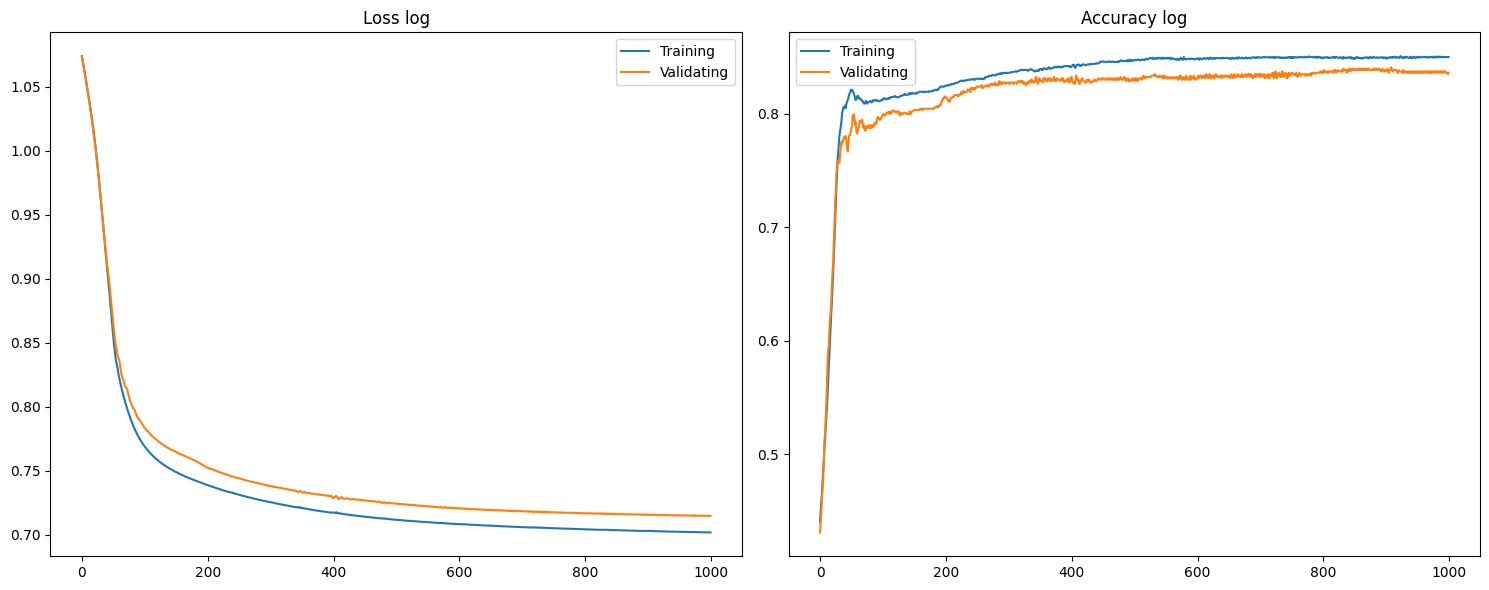

In [90]:
train_loss = []
train_acc = []
val_loss = []
val_acc = []

for i in range(1, epochs+1):
    model.train()

    optimizer.zero_grad()

    out = model(x_train)
    loss = criterion(out, y_train)

    loss.backward()
    optimizer.step()

    train_loss += [loss.item()]
    acc = (out.argmax(1) == y_train).sum().item()
    train_acc += [acc/y_train.shape[0]]

    model.eval()

    diff = 0
    acc = 0
    total = 0

    with torch.no_grad():
        
        model.anfis.fit_coeff(x_train, y_train)

        out = model(x_val)
        loss = criterion(out, y_val)

        acc = (out.argmax(1) == y_val).sum().item()
        

        val_loss += [loss.item()]
        val_acc += [acc/y_val.shape[0]]

    if i%100 == 0:

        print("Epoch {} train loss {} acc {} val loss {} acc {}".format(i, train_loss[-1], train_acc[-1],
                                                                   val_loss[-1], val_acc[-1]))

fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

index = 0

axes[index].plot(train_loss, label="Training")
axes[index].plot(val_loss, label="Validating")
axes[index].set_title("Loss log")
axes[index].legend()

index += 1

axes[index].plot(train_acc, label="Training")
axes[index].plot(val_acc, label="Validating")
axes[index].set_title("Accuracy log")
axes[index].legend()
plt.tight_layout()
plt.show()

# ANFIS testing

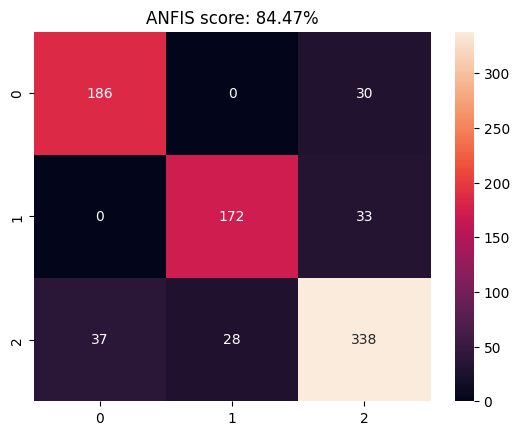

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       216
           1       0.86      0.84      0.85       205
           2       0.84      0.84      0.84       403

    accuracy                           0.84       824
   macro avg       0.85      0.85      0.85       824
weighted avg       0.84      0.84      0.84       824



In [91]:
y_pred = model(x_test)

y_pred = y_pred.argmax(1).cpu().detach().numpy()

score = accuracy_score(y_pred, y_test)
report = classification_report(y_pred, y_test)
cm = confusion_matrix(y_pred, y_test)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("ANFIS score: {}%".format(round(score*100, 2)))
plt.show()

print(report)